# MTPA Neural Network Training — PyTorch

이 노트북은 `MTPA_NN.py`의 주요 설정과 학습 규칙을 동일하게 반영한 셀 기반 버전입니다.

- 입력: CSV의 **3번째 열** (`idx_x = [2]`)
- 출력: CSV의 **1~2번째 열** (`idx_y = [0, 1]`)
- 모델: `1 → 20 → 2`, 은닉층 ReLU
- 입력 정규화: `MINMAX`
- 출력 정규화: `None`
- Train/Test 분할: 무작위 `60% / 40%`
- Optimizer: Adam, 초기 학습률 `0.004`
- 학습률: 매 epoch `0.999` 배 감쇠
- L2 항: `0.0001 × Σ||parameter||₂`
- Batch size: `16`
- Epoch: `2000`
- 결과: 모델, loss 그래프, MTPA 예측 비교 그래프 및 CSV 저장

> 아래 셀을 위에서부터 순서대로 실행하세요.


In [ ]:
# 1. 라이브러리 불러오기 및 결과 폴더 생성

import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from google.colab import drive

# GitHub repository를 저장할 위치
REPO_ROOT = "/content/MTPA_example_copy"
# 저장소가 없으면 clone
if not os.path.exists(REPO_ROOT):
    !git clone -q https://github.com/Jaehoon-Shim/MTPA_example.git {REPO_ROOT}

os.makedirs('/content/MTPA_example_copy/data', exist_ok=True)
os.makedirs('/content/MTPA_example_copy/results', exist_ok=True)

print('PyTorch version:', torch.__version__)
print('Working directory:', os.getcwd())


Mounted at /content/drive
PyTorch version: 2.11.0+cpu
Working directory: /content


In [ ]:
# 2. 주요 설정값
# 데이터 경로
DIRECTORY = '/content/MTPA_example_copy/data/MTPA_FEA_v2.csv'
RESULTS_DIR = '/content/MTPA_example_copy/results/'
CSV_PATH = os.path.join(RESULTS_DIR, 'test.csv')
# 모델 입출력 및 은닉 노드 수
IN_NUM = 1
HID_NUM = 20
OUT_NUM = 2
# 학습 설정
INITIAL_LR = 0.004
L2_LAMBDA = 0.0001
DECAY_RATE = 0.999
NUM_EPOCHS = 400
BATCH_SIZE = 16
PRINT_INTERVAL = 10
# 데이터 설정
NORM_FOR_X = 'MINMAX'   # None, MINMAX, STD, PU
NORM_FOR_Y = 'MINMAX'     # None, MINMAX, STD, PU
IDX_X = [2]
IDX_Y = [0, 1]
TEST_DATA_RATIO = 0.4
# 재현 가능한 분할이 필요할 때 사용합니다.
RANDOM_SEED = None
# 저장 경로
MODEL_PATH = os.path.join(RESULTS_DIR, 'model.pt')
STATE_DICT_PATH = os.path.join(RESULTS_DIR, 'model_state_dict.pt')
LOSS_FIG_PATH = os.path.join(RESULTS_DIR, 'training_loss.jpg')
PRED_FIG_PATH = os.path.join(RESULTS_DIR, 'predicted_vs_true.jpg')
PRED_CSV_PATH = os.path.join(RESULTS_DIR, 'test_prediction.csv')
LOSS_CSV_PATH = os.path.join(RESULTS_DIR, 'loss_history.csv')

if RANDOM_SEED is not None:
    random.seed(RANDOM_SEED)
    np.random.seed(RANDOM_SEED)
    torch.manual_seed(RANDOM_SEED)
print('CSV path:', DIRECTORY)
print('CSV exists:', os.path.exists(DIRECTORY))

CSV path: /content/drive/MyDrive/Colab Notebooks/MTPA_example/data/MTPA_FEA_v2.csv
CSV exists: True


## 정규화 및 역정규화 함수

`MINMAX`, `STD`, `PU`, `None` 방식 제공


In [3]:
# 3. 정규화 / 역정규화 함수
EPS = 1e-6
def normalize(method, data):
    if method == 'MINMAX':
        data = data.values
        data_min = np.min(data, axis=0)
        data_max = np.max(data, axis=0)
        normalized_data = (data - data_min) / ((data_max - data_min) + EPS)
        return normalized_data, data_min, data_max
    elif method == 'STD':
        data = data.values
        data_mean = np.mean(data, axis=0)
        data_std = np.std(data, axis=0)
        normalized_data = (data - data_mean) / (data_std + EPS)
        return normalized_data, data_mean, data_std
    elif method == 'PU':
        data = data.values
        data_abs_max = np.max(np.abs(data), axis=0)
        normalized_data = data / (data_abs_max + EPS)
        return normalized_data, data_abs_max
    elif method == 'None':
        data = data.values
        return data, None
    else:
        raise ValueError(f'Unknown normalization method: {method}')

def denormalize(method, norm_data, *params):
    if method == 'MINMAX':
        data_min, data_max = params
        return norm_data * (data_max - data_min + EPS) + data_min
    elif method == 'STD':
        data_mean, data_std = params
        return norm_data * (data_std + EPS) + data_mean
    elif method == 'PU':
        data_abs_max = params[0]
        return norm_data * (data_abs_max + EPS)
    elif method == 'None':
        return norm_data
    else:
        raise ValueError(f'Unknown denormalization method: {method}')


## 신경망 모델

 `Linear(1, 20) → ReLU → Linear(20, 2)` 구조입니다.

  `Dropout(0.01)` 은 `forward()`에서 선택적으로 사용가능.

In [4]:
# 4. 신경망 모델 정의

class NN(nn.Module):
    def __init__(self, in_num, hid_num, out_num):
        super().__init__()
        self.l1 = nn.Linear(in_num, hid_num)
        self.dropout = nn.Dropout(0.01)
        self.l2 = nn.Linear(hid_num, out_num)

    def forward(self, x):
        x = torch.relu(self.l1(x))
        x = self.l2(x)
        return x


model = NN(in_num=IN_NUM, hid_num=HID_NUM, out_num=OUT_NUM)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=INITIAL_LR)

print(model)


NN(
  (l1): Linear(in_features=1, out_features=20, bias=True)
  (dropout): Dropout(p=0.01, inplace=False)
  (l2): Linear(in_features=20, out_features=2, bias=True)
)


In [5]:
# 5. CSV 로드 및 입력/출력 열 선택

if not os.path.exists(DIRECTORY):
    raise FileNotFoundError(
        f'CSV 파일을 찾을 수 없습니다: {DIRECTORY}\n'
        'MTPA_FEA.csv를 data 폴더에 넣거나 DIRECTORY를 실제 경로로 수정하세요.'
    )

data = pd.read_csv(DIRECTORY)
data = data.loc[:, ~data.columns.astype(str).str.startswith('Unnamed')]

x_data = pd.DataFrame(data.iloc[:, IDX_X])
y_data = pd.DataFrame(data.iloc[:, IDX_Y])

# 숫자가 아닌 값 또는 결측값이 포함된 행 제거
combined = pd.concat([x_data, y_data], axis=1).apply(pd.to_numeric, errors='coerce').dropna()
x_data = combined.iloc[:, :len(IDX_X)].copy()
y_data = combined.iloc[:, len(IDX_X):].copy()

print('전체 데이터 형상:', data.shape)
print('사용 데이터 개수:', len(x_data))
print('입력 열:', data.columns[IDX_X].tolist())
print('출력 열:', data.columns[IDX_Y].tolist())
display(combined.head())


전체 데이터 형상: (258, 3)
사용 데이터 개수: 258
입력 열: ['0.1']
출력 열: ['0.01', '0']


,0.1,0.01,0
0,0.957858,-0.002782,1
1,1.915760,-0.010564,2
2,2.873640,-0.013345,3
3,3.831630,-0.026127,4
4,4.789620,-0.033909,5


In [6]:
# 6. Train/Test 무작위 분할 —  60% / 40%

data_length = len(x_data)
indices = np.arange(data_length)
test_length = int(data_length * TEST_DATA_RATIO)

np.random.shuffle(indices)
test_indices = np.sort(indices[:test_length])
train_indices = np.sort(indices[test_length:])

x_tr = x_data.iloc[train_indices]
x_te = x_data.iloc[test_indices]
y_tr = y_data.iloc[train_indices]
y_te = y_data.iloc[test_indices]

print('Train samples:', len(train_indices))
print('Test samples :', len(test_indices))
print('Train ratio  :', len(train_indices) / data_length)
print('Test ratio   :', len(test_indices) / data_length)


Train samples: 155
Test samples : 103
Train ratio  : 0.6007751937984496
Test ratio   : 0.3992248062015504


## 데이터 정규화

Train과 Test 데이터에 각각 `normalize()`를 호출합니다. 따라서 Test 입력의 MINMAX 범위도 Test 데이터 자체에서 계산됩니다.


In [7]:
# 7. 정규화, Tensor 변환 및 DataLoader 생성

x_tr_norm, *x_params = normalize(NORM_FOR_X, x_tr)
x_te_norm, *x_te_params = normalize(NORM_FOR_X, x_te)
y_tr_norm, *y_params = normalize(NORM_FOR_Y, y_tr)
y_te_norm, *y_te_params = normalize(NORM_FOR_Y, y_te)

print('Train 입력 정규화 파라미터:', x_params)
print('Test 입력 정규화 파라미터 :', x_te_params)
print('Train 출력 정규화 파라미터:', y_params)
print('Test 출력 정규화 파라미터 :', y_te_params)

x_tr_norm = torch.tensor(x_tr_norm, dtype=torch.float32)
x_te_norm = torch.tensor(x_te_norm, dtype=torch.float32)
y_tr_norm = torch.tensor(y_tr_norm, dtype=torch.float32)
y_te_norm = torch.tensor(y_te_norm, dtype=torch.float32)

train_dataset = TensorDataset(x_tr_norm, y_tr_norm)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

test_dataset = TensorDataset(x_te_norm, y_te_norm)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print('x_train tensor:', x_tr_norm.shape)
print('y_train tensor:', y_tr_norm.shape)
print('x_test tensor :', x_te_norm.shape)
print('y_test tensor :', y_te_norm.shape)


Train 입력 정규화 파라미터: [array([3.83163]), array([262.35])]
Test 입력 정규화 파라미터 : [array([0.957858]), array([261.371])]
Train 출력 정규화 파라미터: [array([-70.2296,   4.    ]), array([-2.61274e-02,  2.58000e+02])]
Test 출력 정규화 파라미터 : [array([-69.7459,   1.    ]), array([-2.78176e-03,  2.57000e+02])]
x_train tensor: torch.Size([155, 1])
y_train tensor: torch.Size([155, 2])
x_test tensor : torch.Size([103, 1])
y_test tensor : torch.Size([103, 2])


## 모델 학습

각 epoch에서 학습률을 `INITIAL_LR × DECAY_RATE^epoch`으로 직접 갱신하며, 손실함수는 MSE와 수동 L2 정규화 항의 합입니다.


In [8]:
# 8. 모델 학습
train_losses = []
test_losses = []
lr_history = []

for epoch in range(NUM_EPOCHS):
    # Adaptive learning rate: initial_lr * decay_rate^epoch
    lr = INITIAL_LR * (DECAY_RATE ** epoch)
    for param_group in optimizer.param_groups:
        param_group['lr'] = lr
    lr_history.append(lr)
    model.train()
    epoch_loss = 0.0

    for batch_x, batch_y in train_loader:
        pred = model(batch_x)
        # Reconstruction loss
        loss = criterion(pred, batch_y)
        # L2 regularization
        l2_reg = torch.tensor(0.0)
        for param in model.parameters():
            l2_reg = l2_reg + torch.norm(param, p=2)
        loss = loss + L2_LAMBDA * l2_reg
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * batch_x.size(0)

    train_losses.append(epoch_loss / len(train_loader.dataset))

    # Test loss에는 L2 항을 포함하지 않음
    model.eval()
    test_loss = 0.0
    with torch.no_grad():
        for batch_x, batch_y in test_loader:
            pred = model(batch_x)
            batch_loss = criterion(pred, batch_y)
            test_loss += batch_loss.item() * batch_x.size(0)

    test_losses.append(test_loss / len(test_loader.dataset))

    if (epoch + 1) % PRINT_INTERVAL == 0:
        print(
            f'Epoch [{epoch + 1}/{NUM_EPOCHS}], '
            f'Train Loss: {train_losses[-1]:.6f}, '
            f'Test Loss: {test_losses[-1]:.6f}, '
            f'LR: {lr:.8f}'
        )


Epoch [10/400], Train Loss: 0.003242, Test Loss: 0.001918, LR: 0.00396414
Epoch [20/400], Train Loss: 0.001842, Test Loss: 0.001325, LR: 0.00392468
Epoch [30/400], Train Loss: 0.000921, Test Loss: 0.000327, LR: 0.00388561
Epoch [40/400], Train Loss: 0.000750, Test Loss: 0.000193, LR: 0.00384693
Epoch [50/400], Train Loss: 0.000701, Test Loss: 0.000142, LR: 0.00380863
Epoch [60/400], Train Loss: 0.000674, Test Loss: 0.000093, LR: 0.00377072
Epoch [70/400], Train Loss: 0.000666, Test Loss: 0.000098, LR: 0.00373318
Epoch [80/400], Train Loss: 0.000653, Test Loss: 0.000069, LR: 0.00369601
Epoch [90/400], Train Loss: 0.000651, Test Loss: 0.000049, LR: 0.00365922
Epoch [100/400], Train Loss: 0.000646, Test Loss: 0.000045, LR: 0.00362279
Epoch [110/400], Train Loss: 0.000638, Test Loss: 0.000043, LR: 0.00358673
Epoch [120/400], Train Loss: 0.000634, Test Loss: 0.000040, LR: 0.00355102
Epoch [130/400], Train Loss: 0.000629, Test Loss: 0.000035, LR: 0.00351567
Epoch [140/400], Train Loss: 0.000

In [9]:
# 9. 모델 저장

# 전체 모델 저장
model.eval()
torch.save(model, MODEL_PATH)

# 재사용 편의를 위한 state_dict도 추가 저장
checkpoint = {
    'model_state_dict': model.state_dict(),
    'in_num': IN_NUM,
    'hid_num': HID_NUM,
    'out_num': OUT_NUM,
    'norm_for_x': NORM_FOR_X,
    'norm_for_y': NORM_FOR_Y,
    'x_params': x_params,
    'y_params': y_params,
    'idx_x': IDX_X,
    'idx_y': IDX_Y,
}
torch.save(checkpoint, STATE_DICT_PATH)

print('전체 모델 저장:', MODEL_PATH)
print('체크포인트 저장:', STATE_DICT_PATH)


전체 모델 저장: /content/drive/MyDrive/Colab Notebooks/MTPA_example/results/model.pt
체크포인트 저장: /content/drive/MyDrive/Colab Notebooks/MTPA_example/results/model_state_dict.pt


In [10]:
# 10. Test 데이터 예측, 역정규화 및 실제 스케일 MSE 계산

model.eval()

with torch.no_grad():
    pred = model(x_te_norm).cpu().numpy()

    y_te_pred = denormalize(NORM_FOR_Y, pred, *y_params)
    y_te_real = y_te.values

    test_loss_scaled = criterion(
        torch.tensor(y_te_pred, dtype=torch.float32),
        torch.tensor(y_te_real, dtype=torch.float32)
    )

print(f'Scaled Test Loss (MSE): {test_loss_scaled.item():.6f}')
print('실제값 예시:')
print(y_te_real[:5])
print('예측값 예시:')
print(y_te_pred[:5])


Scaled Test Loss (MSE): 2.149318
실제값 예시:
[[-2.78176e-03  1.00000e+00]
 [-1.05637e-02  2.00000e+00]
 [-1.33451e-02  3.00000e+00]
 [-3.39088e-02  5.00000e+00]
 [-1.07860e-01  8.00000e+00]]
예측값 예시:
[[ 2.83598450e-01  6.87850345e+00]
 [ 2.41603279e-01  7.63519101e+00]
 [ 1.99624845e-01  8.39186721e+00]
 [ 1.15634502e-01  9.90537479e+00]
 [-1.05183899e-02  1.21788704e+01]]


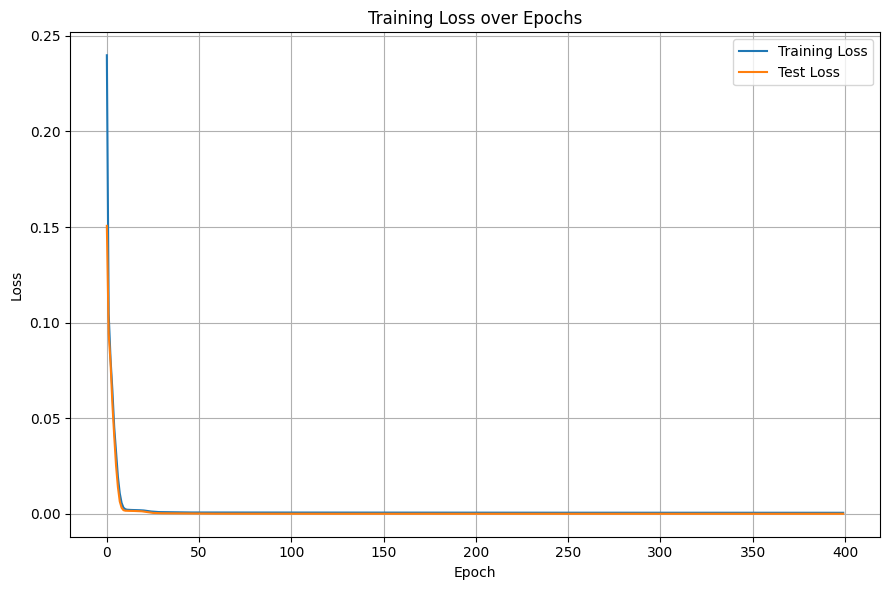

Loss figure saved: /content/drive/MyDrive/Colab Notebooks/MTPA_example/results/training_loss.jpg
Loss CSV saved   : /content/drive/MyDrive/Colab Notebooks/MTPA_example/results/loss_history.csv


In [11]:
# 11. Epoch별 Train/Test loss 그래프 및 CSV 저장

loss_history = pd.DataFrame({
    'epoch': np.arange(1, NUM_EPOCHS + 1),
    'learning_rate': lr_history,
    'train_loss': train_losses,
    'test_loss': test_losses,
})
loss_history.to_csv(LOSS_CSV_PATH, index=False)

plt.figure(figsize=(9, 6))
plt.plot(range(NUM_EPOCHS), train_losses, label='Training Loss')
plt.plot(range(NUM_EPOCHS), test_losses, label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss over Epochs')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig(LOSS_FIG_PATH, dpi=300, bbox_inches='tight')
plt.show()

print('Loss figure saved:', LOSS_FIG_PATH)
print('Loss CSV saved   :', LOSS_CSV_PATH)


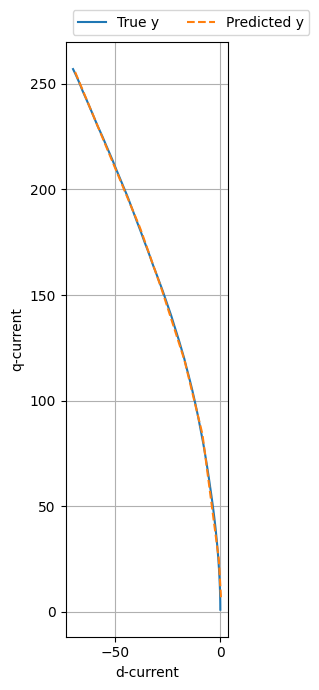

Prediction figure saved: /content/drive/MyDrive/Colab Notebooks/MTPA_example/results/predicted_vs_true.jpg


In [12]:
# 12. MTPA 실제값과 예측값 비교 그래프 저장

plt.figure(figsize=(8, 7))
plt.plot(y_te_real[:, 0], y_te_real[:, 1], label='True y')
plt.plot(
    y_te_pred[:, 0],
    y_te_pred[:, 1],
    linestyle='--',
    label='Predicted y'
)
plt.gca().set_aspect('equal', adjustable='box')
plt.grid(True)
plt.xlabel('d-current')
plt.ylabel('q-current')
plt.legend(loc='lower left', bbox_to_anchor=(0.0, 1.0), ncol=2)
plt.tight_layout()
plt.savefig(PRED_FIG_PATH, dpi=300, bbox_inches='tight')
plt.show()

print('Prediction figure saved:', PRED_FIG_PATH)


In [13]:
# 13. Test 예측 결과 CSV 저장

prediction_df = pd.DataFrame({
    'original_index': test_indices,
    'x_original': x_te.values[:, 0],
    'y1_true': y_te_real[:, 0],
    'y2_true': y_te_real[:, 1],
    'y1_pred': y_te_pred[:, 0],
    'y2_pred': y_te_pred[:, 1],
})

prediction_df.to_csv(PRED_CSV_PATH, index=False)
display(prediction_df.head())

print('Prediction CSV saved:', PRED_CSV_PATH)


,original_index,x_original,y1_true,y2_true,y1_pred,y2_pred
0,0,0.957858,-0.002782,1.0,0.283598,6.878503
1,1,1.915760,-0.010564,2.0,0.241603,7.635191
2,2,2.873640,-0.013345,3.0,0.199625,8.391867
3,4,4.789620,-0.033909,5.0,0.115635,9.905375
4,7,7.667660,-0.107860,8.0,-0.010518,12.178870


Prediction CSV saved: /content/drive/MyDrive/Colab Notebooks/MTPA_example/results/test_prediction.csv


In [14]:
# ============================================================
# 14. 결과 CSV, 학습 이력 CSV, PyTorch 모델(.pt) 저장
# ============================================================


model_cpu = model.to('cpu')
model_cpu.eval()

torch.save(
    model_cpu.state_dict(),
    MODEL_PATH
)

print('Train 입력 정규화 파라미터:', x_params)
print('Test 입력 정규화 파라미터 :', x_te_params)
print('Train 출력 정규화 파라미터:', y_params)
print('Test 출력 정규화 파라미터 :', y_te_params)



Train 입력 정규화 파라미터: [array([3.83163]), array([262.35])]
Test 입력 정규화 파라미터 : [array([0.957858]), array([261.371])]
Train 출력 정규화 파라미터: [array([-70.2296,   4.    ]), array([-2.61274e-02,  2.58000e+02])]
Test 출력 정규화 파라미터 : [array([-69.7459,   1.    ]), array([-2.78176e-03,  2.57000e+02])]
